# 데이터 전처리

## 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = ''
df_ = pd.read_excel(path + './water_quality.xlsx', sheet_name='전국DB',
                    na_values=['-', 'NaN', 'null', 'NULL', '', ' ', 'nan'])

In [2]:
df = df_.copy()

In [3]:
necessary = ['Temp', 'pH', 'EC', 'DO', 'TDS', 'Ca', 'Mg', 'Na', 'K', 'HCO3',
             'Cl', 'SO4', 'NO3', 'F', 'Fe', 'Mn', 'Si', 'CO3', 'SiO2',
             'NH4', '유기인', '비소_As', '세레늄_Se', '수은_Hg', '카드뮴_Cd',
             '파라티온_Parathion', '납_Pb', '톨루엔_Toluene', '에틸벤젠_Ethylbenzene',
             '시안_CN', '크실렌_Xylene', '페놀_Phenol', '망간_Mn', '수소이온농도_pH',
             '트리클로로에탄_1_1_1_TCE', '황산이온_SO4_2', '다이아지논_Diazion',
             '트리클로로에틸렌_TCE', '벤젠_Benzene', '대장균군', '테트라클로로에틸렌',
             '클로로포름', '1_4_다이옥산', '크롬', '용존산소량_DO', '염소이온_Cl_',
             'NO3_N', '질산성질소_NO3_N', 'NH4_N', '총대장균군', '수문지질', '망간_Mn']

can_consider = ['알루미늄_Al', '페니트로티온', '구리_Cu', '세제_ABS',
                '아연_Zn', '사염화탄소', '과망간산칼륨소비량', '보론',
                '1_2_디브로모_3_클로로프로판', '유리잔류염소', '바륨', '니켈', '코발트',
                'TBAC', 'DBRO', '브롬', '티타늄', '바나듐', '갈륨', '저마늄', '몰리브덴']

overlapped = ['수소이온농도_pH', '용존산소량_DO', '염소이온_Cl_', 'NO3_N', '황산이온_SO4_2',
              '질산성질소_NO3_N', 'NH4_N', '총대장균군', '수문지질', '망간_Mn']

meta_col = ['구분', '연도', '시도', '시군구', '읍면동', '리', '번지', 'MW_NAME',
            'SW_NAME']

drop_col = ['공번호', '조사횟수', '조사시기', '1_4_다이옥산', '유기인']

In [4]:
df.shape

(37125, 129)

## 데이터 오류 처리

In [5]:
# column 이름 오타 수정
df = df.rename(columns={'TM_X_5186.1': 'TM_Y_5186'})

In [6]:
# 범주형 feature와 연속형 feature 구분
categorical = []
not_categorical = ['관정심도', '관정구경', 'CO3', '알루미늄_Al']

for column in df.columns:
    if df[column].dtype == object and column not in not_categorical:
        categorical.append(column)
    else:
        df[column] = pd.to_numeric(df[column], errors='coerce')

In [7]:
# 아래 column의 값이 nan인 row는 삭제
col_drop_row_if_null = ['TM_X_5186', 'MW_NAME', '수문지질_상세', '연도']

for col in col_drop_row_if_null:
    df = df.dropna(subset=[col])

In [8]:
# 필요없는 feature 삭제
df = df.drop(columns=drop_col)

In [9]:
# '대수층' feature에는 '알수없음'으로 저장된 값이 있음 -> 이 값을 nan으로 대체
df['대수층'] = df['대수층'].apply(lambda x: np.nan if x == '알수없음' else x)

In [10]:
# 값이 음수이면 0으로 설정
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].applymap(lambda x: max(x, 0))

AttributeError: 'DataFrame' object has no attribute 'applymap'

In [ ]:
# '대장균군' feature에는 str과 int가 함께 쓰임 -> int로 통일
def coli(x):
    ret = 0
    if type(x) == str:
        ret = 1
    elif x != np.nan:
        ret = x
    return ret

df['대장균군'] = df['대장균군'].apply(lambda x: coli(x))
df['총대장균군'] = df['총대장균군'].apply(lambda x: coli(x))

## 결측 비율이 높은 feature 처리

In [ ]:
# 필수 feature가 아닌데 결측 비율이 0.5가 넘는 경우 삭제
# 필수 feature 또는 고려할만한 feature가 아닌데 결측 비율이 0.3이 넘는 경우 삭제
print(f'삭제 전 column 수: {df.shape[1]}')

def drop(column, missing_percent):
    ret = 0
    if missing_percent > 0.5 and column not in necessary:
        ret = 1
    if missing_percent > 0.3 and column not in necessary + can_consider:
        ret = 1
    return ret

row = df.shape[0]
for column in df.columns:
    missing = df[column].isnull().sum()
    missing_percent = missing / row
    if drop(column, missing_percent):
        df = df.drop(columns=[column])

print(f'삭제 후 column 수: {df.shape[1]}')

삭제 전 column 수: 124
삭제 후 column 수: 69


## 위치 기반 결측값 처리

In [ ]:
# 결측값 처리 전 결측값 개수 기록
from collections import defaultdict

missing_val = defaultdict(list)

for column in df.columns:
    missing_val[column].append(df[column].isnull().sum())

In [ ]:
# meta_col을 이용하여 결측값을 유사한 지역의 중앙값 또는 최빈값으로 대체
def group_missing(group_cols, checks):
    for col in checks:
        if col in categorical:
            def safe_mode(x):
                m = x.mode(dropna=True)
                if not m.empty:
                    return m.iloc[0]
                else:
                    return np.nan
            group_mean = df.groupby(group_cols)[col].transform(safe_mode)

        else:
            group_mean = df.groupby(group_cols)[col].transform('median')
        df[col] = df[col].fillna(group_mean)

    # 결측값 개수 변화 기록
    for column in df.columns:
        missing_val[column].append(df[column].isnull().sum())

checks = [column for column in df.columns if column not in meta_col]

group_cols = ['시도', '시군구', 'MW_NAME', 'SW_NAME']
group_missing(group_cols, checks)

group_cols = ['시도', '시군구', 'MW_NAME']
group_missing(group_cols, checks)

group_cols = ['시도', '시군구', '읍면동', '리']
group_missing(group_cols, checks)

group_cols = ['시도', '시군구', '읍면동']
group_missing(group_cols, checks)

In [ ]:
# 위치 기반 결측값 처리 후 결측값 개수 확인
def print_missing():
    for key, val in missing_val.items():
        print(f'{key}: {val[0]}', end='')
        for idx in range(len(val) - 1):
            print(f' -> {val[idx]}', end='')
        print()
print_missing()

구분: 0 -> 0 -> 0 -> 0 -> 0
연도: 0 -> 0 -> 0 -> 0 -> 0
시도: 0 -> 0 -> 0 -> 0 -> 0
시군구: 0 -> 0 -> 0 -> 0 -> 0
읍면동: 3202 -> 3202 -> 3202 -> 3202 -> 3202
리: 7011 -> 7011 -> 7011 -> 7011 -> 7011
번지: 6940 -> 6940 -> 6940 -> 6940 -> 6940
MW_NAME: 0 -> 0 -> 0 -> 0 -> 0
SW_NAME: 0 -> 0 -> 0 -> 0 -> 0
수문지질: 83 -> 83 -> 0 -> 0 -> 0
수문지질_상세: 0 -> 0 -> 0 -> 0 -> 0
TM_X_5186: 0 -> 0 -> 0 -> 0 -> 0
TM_Y_5186: 0 -> 0 -> 0 -> 0 -> 0
대수층: 6763 -> 6763 -> 4807 -> 4475 -> 4469
Temp: 16976 -> 16976 -> 11680 -> 11214 -> 11207
pH: 13365 -> 13365 -> 8217 -> 7788 -> 7781
EC: 15509 -> 15509 -> 10087 -> 9630 -> 9624
DO: 26885 -> 26885 -> 24439 -> 24145 -> 24143
TDS: 23699 -> 23699 -> 18852 -> 18472 -> 18465
Ca: 2892 -> 2892 -> 1050 -> 1021 -> 1021
Mg: 2945 -> 2945 -> 1050 -> 1021 -> 1021
Na: 2953 -> 2953 -> 728 -> 639 -> 636
K: 3384 -> 3384 -> 717 -> 626 -> 626
HCO3: 4919 -> 4919 -> 2753 -> 2688 -> 2684
Cl: 3078 -> 3078 -> 844 -> 809 -> 806
SO4: 4768 -> 4768 -> 2039 -> 1897 -> 1884
NO3: 4062 -> 4062 -> 1571 -> 1482

## 중복되는 feature 처리

In [ ]:
# 중복되는 feature의 처리 1
#   'pH' column의 값이 NaN이면 같은 열의 '수소이온농도_pH' column의 값을 이용
#   'DO' column의 값이 NaN이면 같은 열의 '용존산소량_DO' column의 값을 이용
#   'Cl' column의 값이 NaN이면 같은 열의 '염소이온_Cl_' column의 값을 이용
#   'NO3' column의 값이 NaN이면 같은 열의 'NO3_N' 또는 '질산성질소_NO3_N' column의 값을 이용
#   'NH4' column의 값이 NaN이면 같은 열의 'NH4_N' column의 값을 이용

df['pH'] = df['pH'].fillna(df['수소이온농도_pH'])
df['DO'] = df['DO'].fillna(df['용존산소량_DO'])
df['Cl'] = df['Cl'].fillna(df['염소이온_Cl_'])
df['NO3'] = df['NO3'].fillna(df['NO3_N'])
df['NO3'] = df['NO3'].fillna(df['질산성질소_NO3_N'])
df['NH4'] = df['NH4'].fillna(df['NH4_N'])
df['Mn'] = df['Mn'].fillna(df['망간_Mn'])
df['SO4'] = df['SO4'].fillna(df['황산이온_SO4_2'])

In [ ]:
# 중복되는 feature의 처리 2
#   '대장균군' column의 값이 NaN이면 같은 열의 '총대장균군' column의 값을 이용
#   '대장균군' column의 값이 nan이면 음성으로 간주
df['대장균군'] = df['대장균군'].fillna(df['총대장균군'])
df['대장균군'] = df['대장균군'].fillna(0)

In [ ]:
# 중복되는 feature 처리 후 삭제
df = df.drop(columns=overlapped)

## 결측 비율이 높은 row 처리

In [ ]:
# 결측치 비율이 50% 이상인 row 삭제
missing_ratio = df.isnull().mean(axis=1)
df = df[missing_ratio < 0.5].copy()

In [ ]:
# 각 column 별 결측값 개수 확인
for column in df.columns:
    missing_cnt = df[column].isnull().sum()
    print(f'{column}: {missing_cnt}, {missing_cnt/df.shape[0]:.5f}')

구분: 0, 0.00000
연도: 0, 0.00000
시도: 0, 0.00000
시군구: 0, 0.00000
읍면동: 3034, 0.08982
리: 6301, 0.18653
번지: 5100, 0.15098
MW_NAME: 0, 0.00000
SW_NAME: 0, 0.00000
수문지질_상세: 0, 0.00000
TM_X_5186: 0, 0.00000
TM_Y_5186: 0, 0.00000
대수층: 3929, 0.11631
Temp: 9384, 0.27780
pH: 2904, 0.08597
EC: 7801, 0.23094
DO: 19148, 0.56684
TDS: 17097, 0.50613
Ca: 688, 0.02037
Mg: 688, 0.02037
Na: 291, 0.00861
K: 291, 0.00861
HCO3: 2014, 0.05962
Cl: 0, 0.00000
SO4: 330, 0.00977
NO3: 894, 0.02647
F: 4450, 0.13173
Fe: 6997, 0.20713
Mn: 1480, 0.04381
Si: 15891, 0.47043
CO3: 13586, 0.40219
SiO2: 6953, 0.20583
NH4: 32065, 0.94923
비소_As: 2227, 0.06593
세레늄_Se: 8952, 0.26501
알루미늄_Al: 6797, 0.20121
페니트로티온: 5508, 0.16306
수은_Hg: 4913, 0.14544
카드뮴_Cd: 4768, 0.14115
파라티온_Parathion: 5090, 0.15068
납_Pb: 3844, 0.11380
톨루엔_Toluene: 3194, 0.09455
에틸벤젠_Ethylbenzene: 3686, 0.10912
시안_CN: 4273, 0.12649
크실렌_Xylene: 3067, 0.09079
페놀_Phenol: 3821, 0.11311
트리클로로에탄_1_1_1_TCE: 3711, 0.10986
다이아지논_Diazion: 5201, 0.15397
트리클로로에틸렌_TCE: 3741, 0.

## 중요 feature 중 결측 비율이 높은 feature 처리

In [ ]:
# 필수 항목 중 결측값이 과한 항목 처리 방향
#   크롬: 이진 데이터로
#   클로로포름: 이진 데이터로
#   NH4: 0.5 이상인 경우에 대해 1로 표시, 나머지는 0으로 (이진데이터)
to_binary = ['크롬', '클로로포름']
for column in to_binary:
    df[column] = df[column].apply(lambda x: 1 if x > 0 else 0)

def handle_nh4(x):
    if x > 2.0:
        return 3
    elif x > 1.5:
        return 2
    elif x > 0.5:
        return 1
    else:
        return 0

df['NH4'] = df['NH4'].apply(lambda x: handle_nh4(x))

## 나머지 결측값 처리

In [ ]:
# 나머지 결측값 처리
#   결측값 비율이 0.15 미만인 경우 median으로 대체
#   otherwise numeric 데이터는 sklearn IterativeImputer로 처리
#   category 데이터는 sklearn KNN
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

for column in df.columns:
    missing = df[column].isnull().sum()
    missing_percent = missing / df.shape[0]

    if missing_percent < 0.15 and column not in categorical:
        df[column] = df[column].fillna(df[column].median())

numeric_df = df.select_dtypes(include=[np.number])

imputer = IterativeImputer(estimator=BayesianRidge(),
                           max_iter=30,
                           random_state=42,
                           min_value=0)
imputed_array = imputer.fit_transform(numeric_df)

imputed_df = pd.DataFrame(imputed_array, columns=numeric_df.columns, index=df.index)
df[numeric_df.columns] = imputed_df

In [ ]:
# '대수층' column 결측값 처리
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer

encoder = OrdinalEncoder()
target_col = ['대수층']
predict_col = [column for column in df.columns if (column not in meta_col) and (column not in categorical)]

df_encoded = df[predict_col + target_col].copy()
df_encoded[target_col] = encoder.fit_transform(df[target_col])

imputer = KNNImputer(n_neighbors=3)
df_imputed_array = imputer.fit_transform(df_encoded)

df_imputed = pd.DataFrame(df_imputed_array, columns=predict_col + target_col)
df[target_col] = encoder.inverse_transform(df_imputed[target_col])

In [ ]:
for column in df.columns:
    print(f'{column}: {df[column].isnull().sum()}')

구분: 0
연도: 0
시도: 0
시군구: 0
읍면동: 3034
리: 6301
번지: 5100
MW_NAME: 0
SW_NAME: 0
수문지질_상세: 0
TM_X_5186: 0
TM_Y_5186: 0
대수층: 0
Temp: 0
pH: 0
EC: 0
DO: 0
TDS: 0
Ca: 0
Mg: 0
Na: 0
K: 0
HCO3: 0
Cl: 0
SO4: 0
NO3: 0
F: 0
Fe: 0
Mn: 0
Si: 0
CO3: 0
SiO2: 0
NH4: 0
비소_As: 0
세레늄_Se: 0
알루미늄_Al: 0
페니트로티온: 0
수은_Hg: 0
카드뮴_Cd: 0
파라티온_Parathion: 0
납_Pb: 0
톨루엔_Toluene: 0
에틸벤젠_Ethylbenzene: 0
시안_CN: 0
크실렌_Xylene: 0
페놀_Phenol: 0
트리클로로에탄_1_1_1_TCE: 0
다이아지논_Diazion: 0
트리클로로에틸렌_TCE: 0
아연_Zn: 0
사염화탄소: 0
과망간산칼륨소비량: 0
벤젠_Benzene: 0
대장균군: 0
테트라클로로에틸렌: 0
1_2_디브로모_3_클로로프로판: 0
클로로포름: 0
브롬: 0
크롬: 0


In [ ]:
# column 명 재설정 (snake_case)
df = df.reset_index(drop=True)
df = df.rename(columns={
  '구분': 'region_category',
  '연도': 'year',
  '시도': 'province',
  '시군구': 'city_district',
  '읍면동': 'township',
  '리': 'village',
  '번지': 'lot_number',
  'MW_NAME': 'mw_name',
  'SW_NAME': 'sw_name',
  '수문지질_상세': 'hydrogeology',
  'TM_X_5186': 'X',
  'TM_Y_5186': 'Y',
  '대수층': 'aquifer',
  'Temp': 'temperature',
  'pH': 'pH',
  'EC': 'electrical_conductivity',
  'DO': 'dissolved_oxygen',
  'TDS': 'total_dissolved_solids',
  'Ca': 'calcium',
  'Mg': 'magnesium',
  'Na': 'sodium',
  'K': 'potassium',
  'HCO3': 'bicarbonate',
  'Cl': 'chloride',
  'SO4': 'sulfate',
  'NO3': 'nitrate',
  'F': 'flouirde',
  'Fe': 'iron',
  'Mn': 'manganese',
  'Si': 'silicon',
  'CO3': 'carbonate',
  'SiO2': 'silica',
  'NH4': 'ammonium',
  '비소_As': 'arsenic',
  '세레늄_Se': 'selenium',
  '알루미늄_Al': 'aluminum',
  '페니트로티온': 'fenitrothion',
  '수은_Hg': 'mercury',
  '카드뮴_Cd': 'cadmium',
  '파라티온_Parathion': 'parathion',
  '납_Pb': 'lead',
  '톨루엔_Toluene': 'toluene',
  '에틸벤젠_Ethylbenzene': 'ethylbenzene',
  '시안_CN': 'cyanide',
  '크실렌_Xylene': 'xylene',
  '페놀_Phenol': 'phenol',
  '트리클로로에탄_1_1_1_TCE': 'trichloroethane',
  '다이아지논_Diazion': 'diazion',
  '트리클로로에틸렌_TCE': 'trichloroethylene',
  '아연_Zn': 'zinc',
  '사염화탄소': 'carbon_tetrachloride',
  '과망간산칼륨소비량': 'permanganate',
  '벤젠_Benzene': 'benzene',
  '대장균군': 'coliform',
  '테트라클로로에틸렌': 'tetrachloroethylene',
  '1_2_디브로모_3_클로로프로판': 'dibromo_chloropropane',
  '클로로포름': 'chloroform',
  '브롬': 'bromine',
  '크롬': 'chromium'
})
print(df.columns)

Index(['region_category', 'year', 'province', 'city_district', 'township',
       'village', 'lot_number', 'mw_name', 'sw_name', 'hydrogeology', 'X', 'Y',
       'aquifer', 'temperature', 'pH', 'electrical_conductivity',
       'dissolved_oxygen', 'total_dissolved_solids', 'calcium', 'magnesium',
       'sodium', 'potassium', 'bicarbonate', 'chloride', 'sulfate', 'nitrate',
       'flouirde', 'iron', 'manganese', 'silicon', 'carbonate', 'silica',
       'ammonium', 'arsenic', 'selenium', 'aluminum', 'fenitrothion',
       'mercury', 'cadmium', 'parathion', 'lead', 'toluene', 'ethylbenzene',
       'cyanide', 'xylene', 'phenol', 'trichloroethane', 'diazion',
       'trichloroethylene', 'zinc', 'carbon_tetrachloride', 'permanganate',
       'benzene', 'coliform', 'tetrachloroethylene', 'dibromo_chloropropane',
       'chloroform', 'bromine', 'chromium'],
      dtype='object')


In [ ]:
# 데이터 csv로 내보내기
path = '/content/drive/MyDrive/underground_water_big_data_contest/'
df.to_csv(path + 'df_preprocessed.csv', index=False)

# 수질 데이터를 통해 수질 오염 원인 군집화

In [ ]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/underground_water_big_data_contest/'
df = pd.read_csv(path + 'df_preprocessed.csv')

In [ ]:
df.head()

,region_category,year,province,city_district,township,village,lot_number,mw_name,sw_name,hydrogeology,...,zinc,carbon_tetrachloride,permanganate,benzene,coliform,tetrachloroethylene,dibromo_chloropropane,chloroform,bromine,chromium
0,대구지역,2004.0,대구광역시,북구,국우동,NaN,661,금호강,팔거천,f,...,0.012,0.0,1.2,0.002,1.0,0.0,0.000004,0.0,0.018925,0.0
1,대구지역,2004.0,대구광역시,북구,국우동,NaN,382,금호강,팔거천,f,...,0.020,0.0,2.1,0.002,1.0,0.0,0.000003,0.0,0.000000,0.0
2,대구지역,2004.0,대구광역시,북구,노곡동,NaN,367,금호강,금호강하류,d,...,0.022,0.0,1.5,0.002,1.0,0.0,0.000004,0.0,0.193816,0.0
3,대구지역,2004.0,대구광역시,북구,도남동,NaN,720-2,금호강,팔거천,f,...,0.020,0.0,0.6,0.002,1.0,0.0,0.000003,0.0,0.000000,0.0
4,대구지역,2004.0,대구광역시,북구,도남동,NaN,361,금호강,팔거천,f,...,0.020,0.0,5.0,0.002,1.0,0.0,0.000003,0.0,0.000000,0.0


In [ ]:
meta_col = ['region_category', 'year', 'province', 'city_district', 'township', 'village',
            'lot_number', 'mw_name', 'sw_name']

feature_col = [column for column in df.columns if column not in meta_col]

categorical_col = ['hydrogeology', 'aquifer']

numeric_col = [column for column in feature_col if column not in categorical_col]

In [ ]:
X = df[feature_col].copy()

In [ ]:
# categorical feature ('hydrogeology', 'aquifer') OneHotEncoding 수행
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder()

ct = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_col)],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)
print(X_encoded.shape)

(33780, 65)


In [ ]:
'''
OneHotEncoding 된 결과를 dataframe으로 변환하는 코드
X_df = pd.DataFrame(X_encoded, columns=ct.get_feature_names_out())
X_df.head()
'''

# OneHotEncoding된 후 column을 확인
print(ct.get_feature_names_out())

['cat__hydrogeology_a' 'cat__hydrogeology_b' 'cat__hydrogeology_c'
 'cat__hydrogeology_d' 'cat__hydrogeology_e-1' 'cat__hydrogeology_e-2'
 'cat__hydrogeology_f' 'cat__hydrogeology_g' 'cat__hydrogeology_h-1'
 'cat__hydrogeology_h-2' 'cat__hydrogeology_수류지역' 'cat__aquifer_샘물'
 'cat__aquifer_암반' 'cat__aquifer_암반 ' 'cat__aquifer_용천수'
 'cat__aquifer_지표수' 'cat__aquifer_충적' 'remainder__X' 'remainder__Y'
 'remainder__temperature' 'remainder__pH'
 'remainder__electrical_conductivity' 'remainder__dissolved_oxygen'
 'remainder__total_dissolved_solids' 'remainder__calcium'
 'remainder__magnesium' 'remainder__sodium' 'remainder__potassium'
 'remainder__bicarbonate' 'remainder__chloride' 'remainder__sulfate'
 'remainder__nitrate' 'remainder__flouirde' 'remainder__iron'
 'remainder__manganese' 'remainder__silicon' 'remainder__carbonate'
 'remainder__silica' 'remainder__ammonium' 'remainder__arsenic'
 'remainder__selenium' 'remainder__aluminum' 'remainder__fenitrothion'
 'remainder__mercury' 'remainde

In [ ]:
# StandardScaler 적용: 평균을 0, 분산을 1로 조정
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

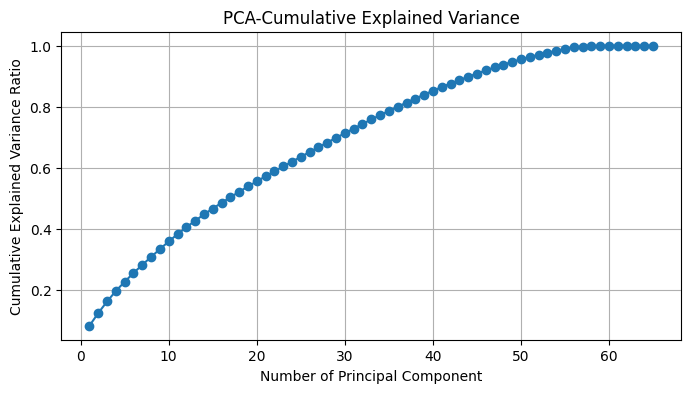

minimum principal component to achive 80% cumulative explained variance ratio: 36


In [ ]:
# 군집화 전 차원 축소: PCA 알고리즘 적용
# Cumulative explained variance ratio를 80% 이상 유지하기 위해서는 차원 수가 30 이상이 되어야 함, 다른 방식 필요
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cumulative_ratio = np.cumsum(pca.explained_variance_ratio_)

# Cumulative Explained Variance Ratio 시각화
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumulative_ratio)+1), cumulative_ratio, marker='o')
plt.xlabel('Number of Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA-Cumulative Explained Variance')
plt.grid(True)
plt.show()

total_ratio = 0
for i, ratio in enumerate(pca.explained_variance_ratio_):
    total_ratio += ratio
    if total_ratio >= 0.8:
        print(f'minimum principal component to achive 80% cumulative explained variance ratio: {i}')
        break

minimum principal component to achieve 80% cumulative explained variance ratio: 37


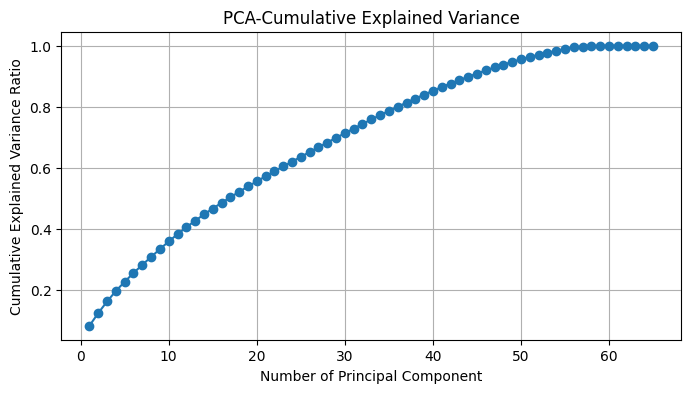

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA 수행
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 누적 설명 분산 비율 계산
cumulative_ratio = np.cumsum(pca.explained_variance_ratio_)

# Cumulative Explained Variance Ratio 시각화
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumulative_ratio)+1), cumulative_ratio, marker='o')
plt.xlabel('Number of Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA-Cumulative Explained Variance')
plt.grid(True)

# 그래프를 파일로 저장 (현재 작업 디렉토리에 저장됩니다)
plt.savefig('pca_cumulative_variance.png', dpi=300, bbox_inches='tight')

# 화면에도 띄우고 싶으면 아래 주석 해제
# plt.show()

# 80%를 달성하기 위한 최소 컴포넌트 개수 계산
total_ratio = 0
for i, ratio in enumerate(pca.explained_variance_ratio_):
    total_ratio += ratio
    if total_ratio >= 0.8:
        print(f'minimum principal component to achieve 80% cumulative explained variance ratio: {i+1}')
        break

## UMAP + DBSCAN tuing

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


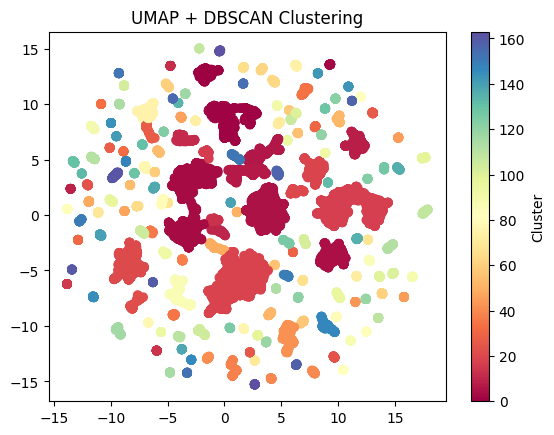

In [ ]:
# UMAP + DBSCAN 방식 적용
# 시각화를 위해 UMAP의 n_components 하이퍼파라미터를 2로 설정
import umap
from sklearn.cluster import DBSCAN

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_umap)

# UMAP + DBSCAN 결과 시각화 (n_components=2 일때만 가능)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='Spectral')
plt.title('UMAP + DBSCAN Clustering')
plt.colorbar(label='Cluster')
plt.show()

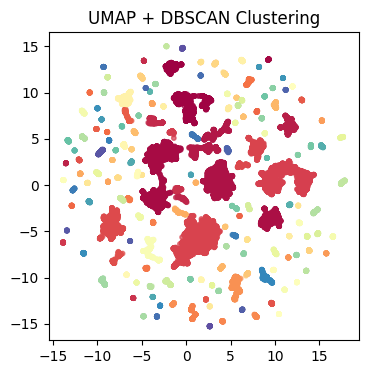

In [ ]:
plt.figure(figsize=(4, 4))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap='Spectral',
    s=10,
    alpha=0.7
)
plt.title('UMAP + DBSCAN Clustering')
# plt.colorbar(label='Cluster')  # ← 컬러바는 주석 처리 또는 삭제

# 파일로 저장
plt.savefig('umap_dbscan.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# UMAP(n_components=2), DBSCAN(eps=0.5, min_samples=5)
def print_result(labels):
    unique_vals, cnts = np.unique(labels, return_counts=True)

    big_cluster_cnt = 0
    for val, cnt in zip(unique_vals, cnts):
        if cnt > 500:
            print(f'Label {val}: {cnt}개')
            big_cluster_cnt += cnt
    print(f'number of datasets that belongs to big clusters: {big_cluster_cnt}')
    print(f'total cluster count: {len(cnts)}')

print_result(labels)

Label 0: 711개
Label 1: 1739개
Label 3: 4097개
Label 4: 1271개
Label 5: 2869개
Label 6: 638개
Label 7: 583개
Label 8: 648개
Label 17: 3829개
Label 18: 4913개
Label 19: 973개
Label 21: 1758개
Label 42: 714개
Label 75: 582개
number of datasets that belongs to big clusters: 25325
total cluster count: 164


In [ ]:
# UMAP(n_components=5), DBSCAN(eps=0.5, min_samples=5)
reducer = umap.UMAP(n_components=5, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_umap)

print_result(labels)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Label 0: 799개
Label 3: 1626개
Label 4: 2414개
Label 5: 3268개
Label 8: 1082개
Label 12: 595개
Label 17: 4051개
Label 18: 5221개
Label 19: 2637개
Label 20: 1781개
Label 25: 757개
Label 29: 874개
Label 38: 633개
number of datasets that belongs to big clusters: 25738
total cluster count: 123


In [ ]:
# UMAP(n_components=10), DBSCAN(eps=0.5, min_samples=5)
reducer = umap.UMAP(n_components=10, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_umap)

print_result(labels)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Label 0: 800개
Label 1: 732개
Label 3: 1641개
Label 4: 2413개
Label 5: 3284개
Label 8: 1082개
Label 11: 1497개
Label 16: 4207개
Label 17: 5595개
Label 18: 2633개
Label 19: 1730개
Label 41: 626개
Label 64: 616개
number of datasets that belongs to big clusters: 26856
total cluster count: 119


In [ ]:
# UMAP(n_components=5), DBSCAN(eps=0.75, min_samples=5)
reducer = umap.UMAP(n_components=5, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.75, min_samples=5)
labels = dbscan.fit_predict(X_umap)

print_result(labels)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Label 0: 799개
Label 3: 1690개
Label 4: 2439개
Label 5: 3268개
Label 8: 1111개
Label 12: 595개
Label 16: 4095개
Label 17: 5221개
Label 18: 2637개
Label 19: 1781개
Label 24: 757개
Label 28: 874개
Label 37: 633개
number of datasets that belongs to big clusters: 25900
total cluster count: 118


In [ ]:
# UMAP(n_components=10), DBSCAN(eps=0.75, min_samples=5)
reducer = umap.UMAP(n_components=10, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.75, min_samples=5)
labels = dbscan.fit_predict(X_umap)

print_result(labels)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Label 0: 800개
Label 1: 732개
Label 3: 1641개
Label 4: 2413개
Label 5: 3284개
Label 8: 1082개
Label 11: 1497개
Label 16: 4268개
Label 17: 5595개
Label 18: 2633개
Label 19: 1789개
Label 40: 626개
Label 61: 616개
number of datasets that belongs to big clusters: 26976
total cluster count: 114


## 군집화 결과 확인 및 csv 내보내기.

In [ ]:
# UMAP(n_components=10), DBSCAN(eps=0.5, min_samples=5)
reducer = umap.UMAP(n_components=10, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_umap)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
unique_vals, cnts = np.unique(labels, return_counts=True)

for idx in range(len(labels)):
    val_idx = np.where(unique_vals == labels[idx])[0][0]
    if cnts[val_idx] < 500:
        labels[idx] = -1

print(np.unique(labels, return_counts=False))

[-1  0  1  3  4  5  8 11 16 17 18 19 41 64]


In [ ]:
# DataFrame에 추가한 후 csv로 내보내기
df['water_quality_type'] = pd.DataFrame(labels)

path = '/content/drive/MyDrive/underground_water_big_data_contest/'
df.to_csv(path + 'df_with_water_quality_type.csv', index=False)

In [ ]:
# 'water_quality_type'을 기준으로 numeric col은 평균, categorical col은 최빈값으로 대체
def most_frequent(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

agg_funcs = {col: 'mean' for col in numeric_col}
agg_funcs.update({col: most_frequent for col in categorical_col})

df_grouped = (
    df
    .groupby('water_quality_type')
    .agg(agg_funcs)
    .reset_index()
)
df_grouped = df_grouped.drop(columns=['X', 'Y'])
df_grouped = df_grouped.set_index('water_quality_type')
df_grouped.head()

,temperature,pH,electrical_conductivity,dissolved_oxygen,total_dissolved_solids,calcium,magnesium,sodium,potassium,bicarbonate,...,permanganate,benzene,coliform,tetrachloroethylene,dibromo_chloropropane,chloroform,bromine,chromium,hydrogeology,aquifer
water_quality_type,,,,,,,,,,,,,,,,,,,,,
-1,16.185694,7.046449,309.869861,13.769145,176.401795,26.251537,7.219605,17.017317,3.016516,80.070603,...,1.372720,0.023242,3829.556615,0.000037,1.503183e-06,0.165367,0.366191,0.033651,h-2,암반
0,15.892374,7.130114,374.720048,6.354736,198.693426,37.224525,8.854049,19.537497,4.268188,111.121159,...,2.053580,0.000038,85.393750,0.000005,5.913480e-07,0.000000,0.091388,0.000000,f,충적
1,16.026600,6.897738,338.388114,7.182733,175.247482,24.632086,6.324620,27.861201,3.710711,76.916871,...,1.810722,0.000027,330.260929,0.000003,1.807894e-06,0.000000,0.107247,0.000000,d,충적
3,15.359867,6.876868,331.808772,7.718831,188.366696,27.219683,7.456170,31.472643,6.343433,83.809479,...,3.042787,0.000008,521.448507,0.000004,3.363776e-07,0.000000,0.179784,0.000000,a,충적
4,15.997468,7.004687,640.572043,7.987205,367.096380,50.586131,17.640481,99.051498,4.499308,104.179774,...,1.696958,0.000006,16.732283,0.000040,2.704259e-07,0.000000,0.352009,0.000829,a,암반


In [ ]:
# CSV 내보내기
path = '/content/drive/MyDrive/underground_water_big_data_contest/'
df_grouped.to_csv(path + 'analysis_water_quality_type.csv', index=True)

# 저류댐 입지 예측 모델

## 의존성 설치

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV

In [ ]:
# 평가 지표 출력 함수
def print_result(estimator, X_train, X_test, y_train, y_test):
    y_pred = estimator.predict(X_test)

    train_acc = estimator.score(X_train, y_train)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)

    print(f"train_acc: {train_acc:.4f}")
    print(f"accuracy: {accuracy:.4f}")
    print(f"f1_score: {f1:.4f}")
    print(f"recall_score: {recall:.4f}")
    print(f"precision_score: {precision:.4f}")
    if hasattr(estimator, 'predict_proba'):
        y_prob = estimator.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_prob[:, 1])
        print(f"roc_auc_score: {auc:.4f}")
    if hasattr(estimator, 'get_params'):
        print(f"model_parameter:\n", estimator.get_params())

## 데이터 준비

In [ ]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/underground_water_big_data_contest/'
df = pd.read_csv(path + 'df_for_task2.csv',
                 encoding='cp949',
                 index_col='ID')

In [ ]:
df.columns

Index(['region_category', 'year', 'province', 'city_district', 'township',
       'village', 'lot_number', 'mw_name', 'sw_name', 'hydrogeology', 'X', 'Y',
       'aquifer', 'temperature', 'pH', 'electrical_conductivity',
       'dissolved_oxygen', 'total_dissolved_solids', 'calcium', 'magnesium',
       'sodium', 'potassium', 'bicarbonate', 'chloride', 'sulfate', 'nitrate',
       'flouirde', 'iron', 'manganese', 'silicon', 'carbonate', 'silica',
       'ammonium', 'arsenic', 'selenium', 'aluminum', 'fenitrothion',
       'mercury', 'cadmium', 'parathion', 'lead', 'toluene', 'ethylbenzene',
       'cyanide', 'xylene', 'phenol', 'trichloroethane', 'diazion',
       'trichloroethylene', 'zinc', 'carbon_tetrachloride', 'permanganate',
       'benzene', 'coliform', 'tetrachloroethylene', 'dibromo_chloropropane',
       'chloroform', 'bromine', 'chromium', 'water_quality_type', '관정심도_m의평균',
       '양수능력_m의평균', '취수계획량의평균', '평균양수량의평균', '자연수위_m의평균', '안정수위_m의평균',
       '저류계수의평균', '가뭄취약성 등급', '

In [ ]:
df = df.rename(columns={
    '관정심도_m의평균': 'mean_well_depth',
    '가뭄취약성 등급': 'drought_vulnerability',
    '양수능력_m의평균': 'mean_pumping_capacity',
    '취수계획량의평균': 'mean_planned_withdrawal',
    '평균양수량의평균': 'mean_pumped_volume_per_day',
    '자연수위_m의평균': 'mean_natural_water_level',
    '안정수위_m의평균': 'mean_stable_water_level',
    '저류계수의평균': 'mean_storage_coef',
    '개발가능량': 'developable_yield',
    '개발여부': 'is_developable'
})

In [ ]:
feature_cols = ['hydrogeology', 'aquifer', 'water_quality_type', 'mean_well_depth', 'drought_vulnerability',
                'mean_pumping_capacity', 'mean_planned_withdrawal', 'mean_pumped_volume_per_day',
                'mean_natural_water_level', 'mean_stable_water_level', 'mean_storage_coef']

categorical = ['hydrogeology', 'aquifer', 'water_quality_type']

numerical = [col for col in feature_cols if col not in categorical]

label_col = ['is_developable']

### coast_line_dist feature 추가

<Axes: xlabel='X', ylabel='Y'>

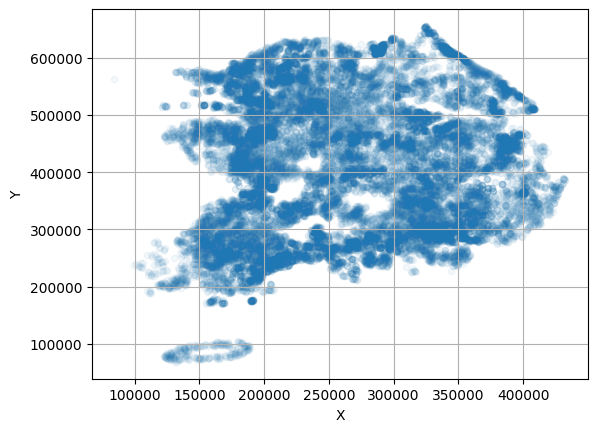

In [ ]:
import matplotlib.pyplot as plt

df.plot(kind='scatter', x='X', y='Y', grid=True, alpha=5e-2)

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['X'], df['Y']),
    crs='EPSG:5186'
)

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
kor = world[world['ADMIN']=='South Korea']
kor = kor.to_crs('EPSG:5186')
coast = kor.boundary.union_all()
gdf['dist_to_coast'] = gdf.geometry.apply(lambda pt: pt.distance(coast))
df['dist_to_coast'] = gdf['dist_to_coast']

feature_cols.append('dist_to_coast')
numerical.append('dist_to_coast')

In [ ]:
# 연속형, 범주형 특성 명시
df[categorical] = df[categorical].astype('str')

for col in numerical:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
max_dist_to_coast = df['dist_to_coast'].max()
min_dist_to_coast = df['dist_to_coast'].min()

print(f"dist_to_coast의 최댓값: {max_dist_to_coast:.4f}")
print(f"dist_to_coast의 최솟값: {min_dist_to_coast:.4f}")

dist_to_coast의 최댓값: 133233.2365
dist_to_coast의 최솟값: 2.7054


### 결측값 채우기

In [ ]:
# 결측값 확인
for column in feature_cols + label_col:
    missing = df[column].isnull().sum()
    missing_percent = missing / df.shape[0]
    print(f"{column}: {missing_percent:.4f}")

hydrogeology: 0.0000
aquifer: 0.0000
water_quality_type: 0.0000
mean_well_depth: 0.2066
drought_vulnerability: 0.2828
mean_pumping_capacity: 0.9768
mean_planned_withdrawal: 0.9783
mean_pumped_volume_per_day: 0.2537
mean_natural_water_level: 0.2057
mean_stable_water_level: 0.3264
mean_storage_coef: 0.6515
dist_to_coast: 0.0000
is_developable: 0.9610


In [ ]:
# mean_pumping_capacity, mean_planned_withdrawal feature (결측 비율이 너무 높음)
feature_cols.remove('mean_pumping_capacity')
feature_cols.remove('mean_planned_withdrawal')

numerical.remove('mean_pumping_capacity')
numerical.remove('mean_planned_withdrawal')

df = df.drop(columns=['mean_pumping_capacity', 'mean_planned_withdrawal'])

In [ ]:
# mean_storage_coef feature: 이진 데이터로 변환
df['mean_storage_coef'] = df['mean_storage_coef'].apply(lambda x: 0 if pd.isna(x) else 1)

In [ ]:
"""
# SimpleImputer를 이용한 결측값 처리: 결측값을 0으로 채우는 것보다 성능이 좋지 않음
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

col_to_fill = ['mean_well_depth', 'drought_vulnerability', 'mean_pumped_volume_per_day',
               'mean_natural_water_level', 'mean_stable_water_level']

df_to_fill = df.select_dtypes(include=[np.number])
df_to_fill = df_to_fill.drop(columns=['is_developable'])

imputer = IterativeImputer(estimator=BayesianRidge(),
                           max_iter=30,
                           random_state=42,
                           min_value=0)
imputed_array = imputer.fit_transform(df_to_fill)

imputed_df = pd.DataFrame(imputed_array, columns=df_to_fill.columns, index=df.index)
df[col_to_fill] = imputed_df[col_to_fill]
"""

"\n# SimpleImputer를 이용한 결측값 처리: 결측값을 0으로 채우는 것보다 성능이 좋지 않음\nfrom sklearn.experimental import enable_iterative_imputer\nfrom sklearn.impute import IterativeImputer\nfrom sklearn.linear_model import BayesianRidge\n\ncol_to_fill = ['mean_well_depth', 'drought_vulnerability', 'mean_pumped_volume_per_day',\n               'mean_natural_water_level', 'mean_stable_water_level']\n\ndf_to_fill = df.select_dtypes(include=[np.number])\ndf_to_fill = df_to_fill.drop(columns=['is_developable'])\n\nimputer = IterativeImputer(estimator=BayesianRidge(),\n                           max_iter=30,\n                           random_state=42,\n                           min_value=0)\nimputed_array = imputer.fit_transform(df_to_fill)\n\nimputed_df = pd.DataFrame(imputed_array, columns=df_to_fill.columns, index=df.index)\ndf[col_to_fill] = imputed_df[col_to_fill]\n"

### 학습 데이터 분리

In [ ]:
# 결측값을 모두 0으로 채움
temp = df[df['is_developable'].notna()]
X = temp[feature_cols].fillna(0)
y = temp[label_col].values.ravel()

print(f"X.shape: {X.shape}, {type(X)}")
print(f"y.shape: {y.shape}, {type(y)}")

X.shape: (1318, 10), <class 'pandas.core.frame.DataFrame'>
y.shape: (1318,), <class 'numpy.ndarray'>


In [ ]:
# 인코딩 및 훈련-데이터 분할
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('scaler', StandardScaler(), numerical)
    ],
    remainder='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")

X_train.shape: (1054, 10)
X_test.shape: (264, 10)


## 모델 실험

### baseline model: dummy classifier

In [ ]:
# Baseline: Dummy Classifier (모든 데이터셋에 대해 0으로 예측)
from sklearn.dummy import DummyClassifier

dummy_pipeline = make_pipeline(
    preprocessor,
    DummyClassifier(strategy='most_frequent')
)

dummy_pipeline.fit(X_train, y_train)

print_result(estimator=dummy_pipeline,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

train_acc: 0.8994
accuracy: 0.8977
f1_score: 0.0000
recall_score: 0.0000
precision_score: 0.0000
roc_auc_score: 0.5000
model_parameter:
 {'memory': None, 'steps': [('columntransformer', ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                                 ['hydrogeology', 'aquifer',
                                  'water_quality_type']),
                                ('scaler', StandardScaler(),
                                 ['mean_well_depth', 'drought_vulnerability',
                                  'mean_pumped_volume_per_day',
                                  'mean_natural_water_level',
                                  'mean_stable_water_level',
                                  'mean_storage_coef', 'dist_to_coast'])])), ('dummyclassifier', DummyClassifier(strategy='most_frequent'))], 'verbose': False, 'columntransformer': ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                            

### RandomForest

In [ ]:
# 기본값으로 훈련 및 평가
from sklearn.ensemble import RandomForestClassifier

randomforest_pipeline = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)
randomforest_pipeline.fit(X_train, y_train)

print_result(estimator=randomforest_pipeline,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

train_acc: 1.0000
accuracy: 0.9811
f1_score: 0.9057
recall_score: 0.8889
precision_score: 0.9231
roc_auc_score: 0.9962
model_parameter:
 {'memory': None, 'steps': [('columntransformer', ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                                 ['hydrogeology', 'aquifer',
                                  'water_quality_type']),
                                ('scaler', StandardScaler(),
                                 ['mean_well_depth', 'drought_vulnerability',
                                  'mean_pumped_volume_per_day',
                                  'mean_natural_water_level',
                                  'mean_stable_water_level',
                                  'mean_storage_coef', 'dist_to_coast'])])), ('randomforestclassifier', RandomForestClassifier(random_state=42))], 'verbose': False, 'columntransformer': ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                       

In [ ]:
# 하이퍼파라미터 튜닝
param_grid = {
    'randomforestclassifier__n_estimators': [250, 300, 350],
    'randomforestclassifier__max_depth': [35, 40, 45],
    'randomforestclassifier__min_samples_split': [2, 3, 4]
}
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=randomforest_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True
)
grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# RandomForest 하이퍼파라미터 튜닝 결과
print_result(estimator=grid.best_estimator_,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)
print(f"best_params_:\n", grid.best_params_)

In [ ]:
search_space = {
    'randomforestclassifier__n_estimators': (270, 330),
    'randomforestclassifier__max_depth': (30, 40),
    'randomforestclassifier__min_samples_split': (2, 4)
}
bayes = BayesSearchCV(
    estimator=randomforest_pipeline,
    search_spaces=search_space,
    scoring='f1',
    cv=cv,
    n_iter=30,
    n_jobs=-1,
    random_state=42
)
bayes.fit(X_train, y_train)

In [ ]:
print_result(estimator=bayes.best_estimator_,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

### SVM

In [ ]:
from sklearn.svm import SVC

svm_pipeline = make_pipeline(
    preprocessor,
    SVC(random_state=42)
)

svm_pipeline.fit(X_train, y_train)
print_result(estimator=svm_pipeline,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

In [ ]:
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True
)
svm_grid.fit(X_train, y_train)
print_result(estimator=svm_grid.best_estimator_,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

### XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_pipeline = make_pipeline(
    preprocessor,
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42)
)
xgb_pipeline.fit(X_train, y_train)
print_result(estimator=xgb_pipeline,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

In [ ]:
import xgboost as xgb

param_grid = {
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__min_child_weight': [1, 3, 5],
    'xgbclassifier__gamma': [0, 0.1, 0.3],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.3],
    'xgbclassifier__n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

In [ ]:
from sklearn import set_config

set_config(display='diagram')
xgb_pipeline

In [ ]:
print_result(estimator=xgb_grid.best_estimator_,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

## SOTA 모델 결과 분석 및 예측 수행

In [ ]:
# best_estimator: XGBoost
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

xgb_pipeline = make_pipeline(
    preprocessor,
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42)
)

xgb_pipeline.fit(X_train, y_train)
y_pred = xgb_pipeline.predict(X_test)

In [ ]:
print_result(estimator=xgb_pipeline,
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)

train_acc: 0.9981
accuracy: 0.9848
f1_score: 0.9231
recall_score: 0.8889
precision_score: 0.9600
roc_auc_score: 0.9980
model_parameter:
 {'memory': None, 'steps': [('columntransformer', ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                                 ['hydrogeology', 'aquifer',
                                  'water_quality_type']),
                                ('scaler', StandardScaler(),
                                 ['mean_well_depth', 'drought_vulnerability',
                                  'mean_pumped_volume_per_day',
                                  'mean_natural_water_level',
                                  'mean_stable_water_level',
                                  'mean_storage_coef', 'dist_to_coast'])])), ('xgbclassifier', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=

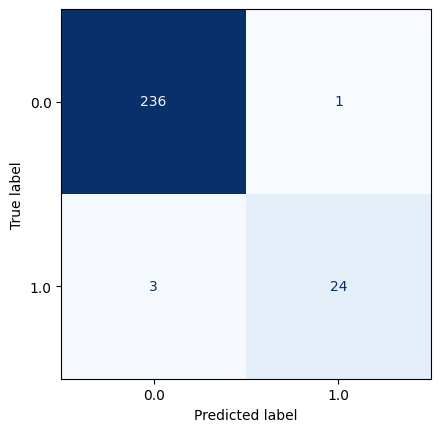

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgb_pipeline, X_test, y_test,
    cmap=plt.cm.Blues,
    colorbar=False
)
plt.show()

## 나머지 데이터에 대해 예측 수행

In [ ]:
# label이 없는 데이터셋 준비
mask_remaining = df['is_developable'].isnull()
remaining = df[mask_remaining == True]

result_predicted = xgb_pipeline.predict(remaining)
result_predicted_prob = xgb_pipeline.predict_proba(remaining)

# DataFrame에 추가
df['result_predicted'] = np.nan
df['result_predicted_prob'] = np.nan
df.loc[mask_remaining, 'result_predicted'] = result_predicted
df.loc[mask_remaining, 'result_predicted_prob'] = result_predicted_prob[:, 1]

In [ ]:
# 결과 csv로 내보내기
output_cols = ['region_category', 'year', 'province', 'city_district', 'township',
               'village', 'lot_number', 'mw_name', 'sw_name', 'is_developable',
               'result_predicted', 'result_predicted_prob']

output = df[output_cols]
output.to_csv(path + 'result.csv')

## XAI

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy import sparse

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42)

xgb.fit(X_train_processed, y_train)

def to_dense_if_sparse(X):
    return X.toarray() if sparse.issparse(X) else X

try:
    # TreeExplainer가 희소행렬을 처리 못하는 환경이면 dense로 변환
    X_bg   = to_dense_if_sparse(X_train_processed)
    X_eval = to_dense_if_sparse(X_test_processed)

    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer(X_eval)          # 최신 shap API
    # 구버전이라면: shap_values = explainer.shap_values(X_eval)
except Exception as e:
    print("[WARN] TreeExplainer 실패 -> KernelExplainer로 폴백:", e)
    # KernelExplainer는 느리므로 background를 소량 샘플
    bg_idx = np.random.choice(X_train_processed.shape[0], size=min(100, X_train_processed.shape[0]), replace=False)
    X_bg = to_dense_if_sparse(X_train_processed[bg_idx])
    X_eval = to_dense_if_sparse(X_test_processed)

    f = lambda data: xgb.predict_proba(data)[:, 1]
    explainer = shap.KernelExplainer(f, X_bg)
    shap_values = explainer.shap_values(X_eval, nsamples=100)  # 속도/정확도 트레이드오프

# 4) 특성 이름(있으면 플롯에 반영)
feature_names = None
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    pass  # 없어도 OK

# 5) 시각화
shap.summary_plot(
    shap_values,
    X_eval,
    feature_names=feature_names,
    show=False,              # << 핵심
    plot_size=(10,6),        # 옵션
    max_display=20           # 옵션
)

fig = plt.gcf()              # summary_plot이 만든 Figure
fig.tight_layout()
fig.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.close(fig)

[WARN] TreeExplainer 실패 -> KernelExplainer로 폴백: 'utf-8' codec can't decode byte 0xb2 in position 626: invalid start byte


  0%|          | 0/264 [00:00<?, ?it/s]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
Glyph 50516 (\N{HANGUL SYLLABLE AM}) missing from font(s) DejaVu Sans.
Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
Glyph 50516 (\N{HANGUL SYLLABLE AM}) missing from font(s) DejaVu Sans.
Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
